# Midterm Data Challenge (Practice)

### Submission

- Deadline: **01:35 PM** (Canvas timestamp strictly enforced).
- Submit your file through "`Canvas` > `Assignment` > `Midterm Exam (Practice)`". - *no grading for practice*
- Submit only the `.ipynb` file (include your full name in the filename).
- No PDF conversion required.


- Total **20 questions** (Part 1 to Part 4), each worth `1.5` point.
  - If the required output is missing: `0` point. (no output = invalid)
  - If the code runs but produces incorrect content: up to `1` points deduction.

- No *Genertive AI, online search, or references* other than tutorial materials and homework.




## [Part 1] Data Loading and Signal Analysis

- Refer to the exam handout **[Part 1]** and write your code accordingly.  
- Print all required outputs from **Problem 1-1 to 1-5**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [1]:
# Import basic packages
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [2]:
!git clone https://github.com/ljwg3000/UNT_MEEN.git

Cloning into 'UNT_MEEN'...
remote: Enumerating objects: 7728, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 7728 (delta 2), reused 4 (delta 1), pack-reused 7718 (from 3)
Receiving objects: 100% (7728/7728), 827.52 MiB | 14.44 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (5669/5669), done.


In [3]:
data_path = "/content/UNT_MEEN/AI_tutorial/IMS_dataset/2nd_test/"

In [4]:
import os

file_list = sorted(os.listdir(data_path))
print("Number of files:", len(file_list))
print(file_list[:3])

Number of files: 984
['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39']


In [5]:
for i in range(len(file_list)):
    temp_PATH = data_path + file_list[i]
    temp_DATA = pd.read_csv(temp_PATH, sep='\t', names=['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4'])
    exec(f"Data_{i+1} = temp_DATA")

# Problem 1-1
Data_1

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054
...,...,...,...,...
20475,0.049,-0.051,-0.039,-0.044
20476,0.037,0.061,0.115,0.007
20477,-0.012,0.007,0.056,-0.007
20478,-0.012,0.093,0.017,-0.044


In [6]:
idx = 700

for i in range(idx):
  exec(f"Normal_{i+1} = Data_{i+1}")

for i in range(idx, len(file_list)):
  exec(f"Abnormal_{i+1-idx} = Data_{i+1}")

NoOfData_Nor = idx
NoOfData_Abn = len(file_list) - idx

# Problem 1-2
print(f"Number of Normal   data: {NoOfData_Nor}")
print(f"Number of Abnormal data: {NoOfData_Abn}")

Number of Normal   data: 700
Number of Abnormal data: 284


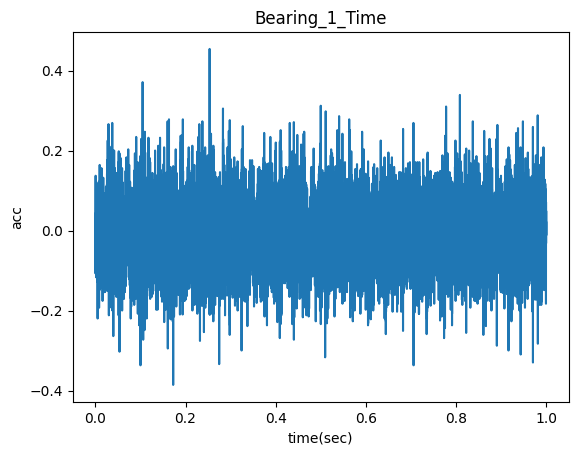

In [8]:
time = np.arange(0, 1, 1/20480)

# Problem 1-3
plt.plot(time, Normal_1.iloc[:,0])
plt.title("Bearing_1_Time")
plt.xlabel("time(sec)")
plt.ylabel("acc")
plt.show()

In [9]:
t = time # Select a time   array of data
x = Normal_1.iloc[:,0].values # Select a signal array of data

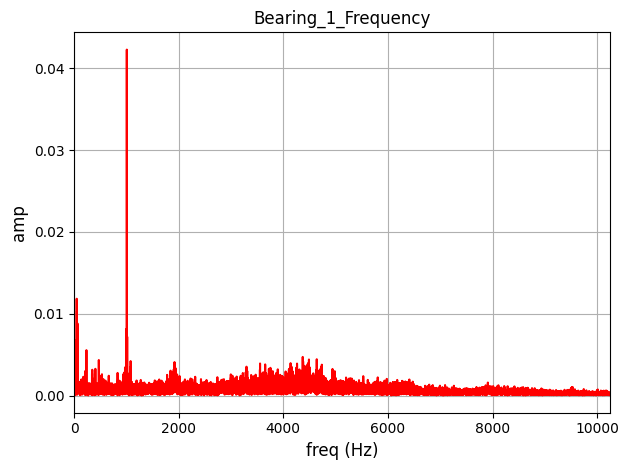

In [12]:
from scipy.fft import fft, fftfreq

dt = np.mean(np.diff(t))
fs = 1.0 / dt

N = len(x)
X = fft(x)
freq = fftfreq(N, 1/fs)

# single-sided
k_pos = N//2
f_pos = freq[:k_pos]
X_pos = X[:k_pos]

# Amplitude scaling
amp = (2 / N) * np.abs(X_pos)
amp[0] = amp[0] / 2
amp[-1] = amp[-1] / 2

# Problem 1-4
# plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'r-')
plt.title('Bearing_1_Frequency')
plt.xlim(0, fs/2)
plt.xlabel('freq (Hz)', fontsize=12)
plt.ylabel('amp', fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

Peak frequencies: [  44.   51.   66.   73.  237. 1002. 1009. 1016.]
Peak amplitudes: [0.0067829  0.01183446 0.00881124 0.00517492 0.0055464  0.00814802
 0.04230154 0.00718387]


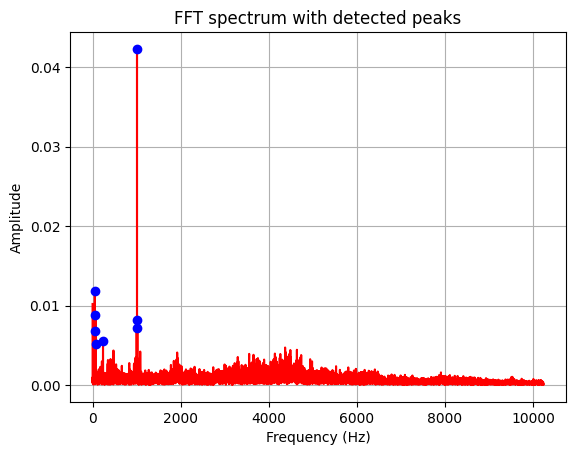

In [14]:
from scipy.signal import find_peaks

# suppose we already have f_pos (Hz) and amp (amplitude spectrum)
peaks, props = find_peaks(amp, height=0.005)  # only peaks above 0.5

# peak frequencies & amplitudes
peak_freqs = f_pos[peaks]
peak_amps = amp[peaks]

# Problem 1-5
print("Peak frequencies:", peak_freqs)

# (Not necessary) print amplitudes of peak components
print("Peak amplitudes:", peak_amps)

# (Not necessary) plot with peaks marked
# plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'r-')
plt.plot(peak_freqs, peak_amps, 'bo')   # mark peaks
# plt.xlim(0, 600)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT spectrum with detected peaks")
plt.grid(True)
plt.show()

.

.

.

## [Part 2] Feature Extraction and Selection

- Refer to the exam handout **[Part 2]** and write your code accordingly.  
- Print all required outputs from **Problem 2-1 to 2-6**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [15]:
# Add cells as many as needed

import scipy.stats as sp
import pywt

In [16]:
NoOfData_Nor = 700
NoOfData_Abn = 284
NoOfSensor  = 2   # 3 Sensor signals: Bearing 1 & 2
NoOfFeature = 5   # 10 Feature types: Max, Min, Mean, RMS, Variance

NoOfData_Nor, NoOfData_Abn, NoOfSensor, NoOfFeature

(700, 284, 2, 5)

In [22]:
# Define RMS function
def rms(x):
    return np.sqrt(np.mean(x**2))

In [17]:
# Create empty(0) arrays for normal/abnormal feature dataset (time domain)
TimeFeature_Normal   = np.zeros((NoOfSensor*NoOfFeature , NoOfData_Nor))
TimeFeature_Abnormal = np.zeros((NoOfSensor*NoOfFeature , NoOfData_Abn))

print(TimeFeature_Normal.shape)
print(TimeFeature_Abnormal.shape)

TimeFeature_Normal

(10, 700)
(10, 284)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [28]:
for i in range(NoOfData_Nor):

    exec(f"temp_data1 = Normal_{i+1}")

    for j in range(NoOfSensor):

        base_index = NoOfFeature * j

        signal_normal   = temp_data1.iloc[:, j+1]

        # Normal features
        TimeFeature_Normal[base_index + 0, i] = np.max(signal_normal)
        TimeFeature_Normal[base_index + 1, i] = np.min(signal_normal)
        TimeFeature_Normal[base_index + 2, i] = np.mean(signal_normal)
        TimeFeature_Normal[base_index + 3, i] = rms(signal_normal)
        TimeFeature_Normal[base_index + 4, i] = np.var(signal_normal)

for i in range(NoOfData_Abn):

    exec(f"temp_data2 = Abnormal_{i+1}")

    for j in range(NoOfSensor):

        base_index = NoOfFeature * j

        signal_abnormal = temp_data2.iloc[:, j+1]


        # Abnormal features
        TimeFeature_Abnormal[base_index + 0, i] = np.max(signal_abnormal)
        TimeFeature_Abnormal[base_index + 1, i] = np.min(signal_abnormal)
        TimeFeature_Abnormal[base_index + 2, i] = np.mean(signal_abnormal)
        TimeFeature_Abnormal[base_index + 3, i] = rms(signal_abnormal)
        TimeFeature_Abnormal[base_index + 4, i] = np.var(signal_abnormal)

# Problem 2-1
print(TimeFeature_Normal.shape)
print(TimeFeature_Abnormal.shape)

(10, 700)
(10, 284)


In [29]:
TimeFeature = np.concatenate([TimeFeature_Normal, TimeFeature_Abnormal] , axis=1)

# Proglem 2-1
print(TimeFeature.shape)

(10, 984)


In [26]:
# Wavelet options
MotherWavelet = pywt.Wavelet('haar')   # Mother wavelet
Level   = 7                            # Wavelet decomposition level

In [27]:
# Create empty(0) arrays for normal/abnormal feature dataset (frequency Domain)
FreqFeature_Normal   = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData_Nor))
FreqFeature_Abnormal = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData_Abn))

print(FreqFeature_Normal.shape)
print(FreqFeature_Abnormal.shape)

FreqFeature_Normal

(70, 700)
(70, 284)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [30]:
for i in range(NoOfData_Nor):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data1 = Normal_{i+1}.iloc[:, 1:]")

    # Wavelet decomposition
    Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in range(Level):

            # Base index for rows
            base_index_sensor = NoOfFeature * Level * j
            base_index_level  = NoOfFeature * k

            base_index        = base_index_sensor + base_index_level

            # Select wavelet coefficients
            coef_normal   = Coef1[Level-k]
            signal_normal   = coef_normal[:, j]

            # Normal features
            FreqFeature_Normal[base_index + 0, i] = np.max(signal_normal)
            FreqFeature_Normal[base_index + 1, i] = np.min(signal_normal)
            FreqFeature_Normal[base_index + 2, i] = np.mean(signal_normal)
            FreqFeature_Normal[base_index + 3, i] = rms(signal_normal)
            FreqFeature_Normal[base_index + 4, i] = np.var(signal_normal)


for i in range(NoOfData_Abn):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data2 = Abnormal_{i+1}.iloc[:, 1:]")

    # Wavelet decomposition
    Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in range(Level):

            # Base index for rows
            base_index_sensor = NoOfFeature * Level * j
            base_index_level  = NoOfFeature * k

            base_index        = base_index_sensor + base_index_level

            # Select wavelet coefficients
            coef_abnormal = Coef2[Level-k]
            signal_abnormal = coef_abnormal[:, j]

            # Abnormal features
            FreqFeature_Abnormal[base_index + 0, i] = np.max(signal_abnormal)
            FreqFeature_Abnormal[base_index + 1, i] = np.min(signal_abnormal)
            FreqFeature_Abnormal[base_index + 2, i] = np.mean(signal_abnormal)
            FreqFeature_Abnormal[base_index + 3, i] = rms(signal_abnormal)
            FreqFeature_Abnormal[base_index + 4, i] = np.var(signal_abnormal)

# Problem 2-2
print(FreqFeature_Normal.shape)
print(FreqFeature_Abnormal.shape)

FreqFeature_Normal

(70, 700)
(70, 284)


array([[ 4.81539718e-01,  3.64159992e-01,  4.87196572e-01, ...,
         3.16076731e-01,  3.41532575e-01,  3.62038672e-01],
       [-3.67695526e-01, -4.68104689e-01, -4.53962554e-01, ...,
        -5.35279833e-01, -3.12541197e-01, -2.87085353e-01],
       [-7.87899255e-05, -2.34643442e-04,  6.45303991e-04, ...,
         4.55199990e-04, -6.39434453e-05,  2.62195747e-04],
       ...,
       [ 1.10656687e-02,  4.61276689e-04, -6.98544160e-03, ...,
         8.18697070e-04, -1.07170872e-04, -2.73064752e-03],
       [ 1.26836418e-01,  1.31728754e-01,  1.25473508e-01, ...,
         9.67581770e-02,  1.08377986e-01,  8.84396607e-02],
       [ 1.59650280e-02,  1.73522518e-02,  1.56948047e-02, ...,
         9.36147456e-03,  1.17457763e-02,  7.81411715e-03]])

In [31]:
FreqFeature = np.concatenate([FreqFeature_Normal, FreqFeature_Abnormal] , axis=1)

# Problem 2-2
print(FreqFeature.shape)

(70, 984)


In [32]:
Features = np.concatenate([TimeFeature,FreqFeature] , axis=0)

print(Features.shape)
Features

(80, 984)


array([[ 4.64000000e-01,  4.57000000e-01,  4.91000000e-01, ...,
         8.91000000e-01,  7.00000000e-03,  2.00000000e-03],
       [-5.13000000e-01, -4.81000000e-01, -5.03000000e-01, ...,
        -7.52000000e-01,  0.00000000e+00, -2.00000000e-03],
       [-1.26949707e-02, -2.56093750e-03, -1.69545898e-03, ...,
        -1.63222656e-03,  3.73149414e-03, -7.01171875e-04],
       ...,
       [ 1.10656687e-02,  4.61276689e-04, -6.98544160e-03, ...,
        -1.23246502e-03, -5.91097075e-05,  9.77796096e-05],
       [ 1.26836418e-01,  1.31728754e-01,  1.25473508e-01, ...,
         1.52706332e-01,  6.07496705e-03,  4.44761721e-03],
       [ 1.59650280e-02,  1.73522518e-02,  1.56948047e-02, ...,
         2.33177048e-02,  3.69017307e-05,  1.97717380e-05]])

In [35]:
Features_df = pd.DataFrame(Features)

# Problem 2-3
Features_df

,0,1,2,3,4,5,6,7,8,9,...,974,975,976,977,978,979,980,981,982,983
0,0.464000,0.457000,0.491000,0.569000,0.452000,0.574000,0.583000,0.410000,0.457000,0.417000,...,0.708000,0.852000,0.725000,0.676000,0.769000,1.118000,0.908000,0.891000,0.007000,0.002000
1,-0.513000,-0.481000,-0.503000,-0.474000,-0.486000,-0.386000,-0.457000,-0.410000,-0.613000,-0.466000,...,-0.664000,-0.674000,-0.754000,-0.608000,-0.688000,-0.884000,-0.637000,-0.752000,0.000000,-0.002000
2,-0.012695,-0.002561,-0.001695,-0.002393,-0.001559,-0.001453,-0.001696,-0.001744,-0.000801,-0.001717,...,-0.001784,-0.000715,-0.001957,-0.001549,-0.002448,-0.000838,-0.000910,-0.001632,0.003731,-0.000701
3,0.090944,0.093419,0.093718,0.092947,0.095348,0.092405,0.093918,0.093241,0.095859,0.094742,...,0.190857,0.191075,0.171075,0.173196,0.176702,0.218294,0.170817,0.193641,0.004018,0.001239
4,0.008110,0.008721,0.008780,0.008633,0.009089,0.008537,0.008818,0.008691,0.009188,0.008973,...,0.036423,0.036509,0.029263,0.029995,0.031218,0.047652,0.029178,0.037494,0.000002,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.338527,0.336494,0.327567,0.288058,0.299460,0.314839,0.367342,0.306177,0.360978,0.332340,...,0.300432,0.429744,0.415072,0.328451,0.296013,0.380865,0.461652,0.464127,0.009811,0.010430
76,-0.419491,-0.384666,-0.338616,-0.350018,-0.280368,-0.278777,-0.392444,-0.251376,-0.322883,-0.393417,...,-0.375562,-0.373087,-0.300344,-0.355410,-0.300255,-0.341002,-0.305559,-0.378037,-0.010872,-0.009546
77,0.011066,0.000461,-0.006985,0.008485,0.006039,0.006026,0.010989,-0.005881,0.005738,-0.006162,...,-0.000205,-0.001677,0.012930,-0.009330,-0.003788,-0.003821,-0.002331,-0.001232,-0.000059,0.000098
78,0.126836,0.131729,0.125474,0.121532,0.115657,0.119763,0.126838,0.108564,0.121758,0.139204,...,0.151673,0.144904,0.134629,0.136009,0.139135,0.155168,0.163676,0.152706,0.006075,0.004448


In [36]:
# NoOfData_Nor = 700
Normal_FeatureData   = Features_df.iloc[:,:NoOfData_Nor]
Abnormal_FeatureData = Features_df.iloc[:,NoOfData_Nor:]

print(Normal_FeatureData.shape)
print(Abnormal_FeatureData.shape)

(80, 700)
(80, 284)


In [37]:
NoOfFeature = 80

P_value = np.zeros((NoOfFeature , 2))

# t-Test (Result: p-value)
for i in np.arange(NoOfFeature):

    T_test       = np.array(sp.ttest_ind(Normal_FeatureData.iloc[i,:] , Abnormal_FeatureData.iloc[i,:]))
    P_value[i,0] = i          # Index of feature (0~79)
    P_value[i,1] = T_test[1]  # P-value

P_value = pd.DataFrame(P_value, columns=['No.', 'P-value'])
P_value

,No.,P-value
0,0.0,2.349346e-16
1,1.0,7.994654e-17
2,2.0,6.286877e-01
3,3.0,6.133400e-66
4,4.0,8.675386e-59
...,...,...
75,75.0,1.549972e-01
76,76.0,9.619451e-01
77,77.0,2.807369e-01
78,78.0,1.124005e-02


In [38]:
P_value_Rank = P_value.sort_values(['P-value'], ascending=True)

# Problem 2-4
P_value_Rank

,No.,P-value
25,25.0,7.863629e-98
26,26.0,9.335966e-97
63,63.0,8.940027e-94
28,28.0,1.320030e-91
23,23.0,1.099192e-82
...,...,...
11,11.0,7.495174e-01
32,32.0,7.899337e-01
47,47.0,7.967829e-01
17,17.0,8.159959e-01


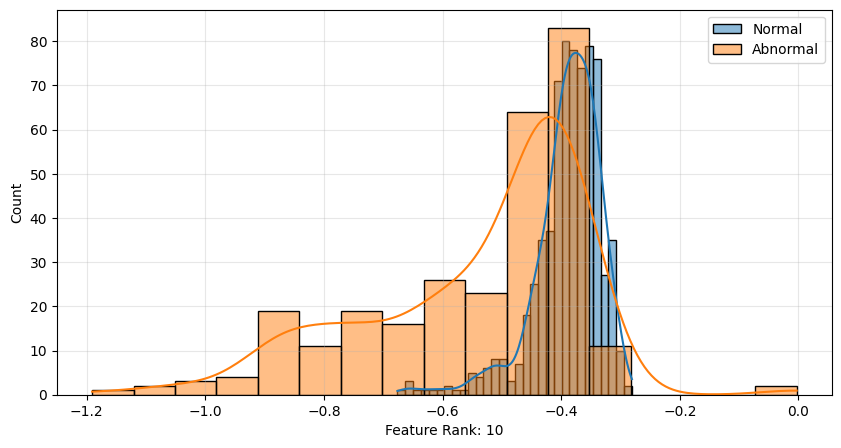

In [40]:
import seaborn           as sb
# P-value Rank (0 ~ 79)
FeatureRank = 9

# Problem 2-5
plt.figure(figsize=(10,5))
sb.histplot(Normal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0])  ,:], kde=True, label = 'Normal')
sb.histplot(Abnormal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0]),:], kde=True, label = 'Abnormal')
plt.legend(loc='best', fontsize=10)
plt.xlabel(f'Feature Rank: {FeatureRank+1}')
plt.grid(alpha=0.3)
plt.show()

In [41]:
Rank = 10  # Select number of rank

Normal   = np.zeros((Rank,NoOfData_Nor))
Abnormal = np.zeros((Rank,NoOfData_Abn))

for i in range(Rank):

    index         = int(P_value_Rank.iloc[i,0])
    Normal[i,:]   = Normal_FeatureData.iloc[index,:].values
    Abnormal[i,:] = Abnormal_FeatureData.iloc[index,:].values

FeatureSelected = pd.DataFrame(np.concatenate([Normal, Abnormal] , axis=1))

print("Selected Feature Data Size :", FeatureSelected.shape)

Selected Feature Data Size : (10, 984)


In [42]:
# Problem 2-6
FeatureSelected

,0,1,2,3,4,5,6,7,8,9,...,974,975,976,977,978,979,980,981,982,983
0,0.436500,0.450750,0.473500,0.456250,0.465000,0.437000,0.524000,0.439250,0.415500,0.429500,...,0.893500,0.944250,0.700500,0.721500,0.948750,1.237500,0.637000,0.895500,0.004500,4.000000e-03
1,-0.348250,-0.374000,-0.435000,-0.418500,-0.443750,-0.585500,-0.401250,-0.446250,-0.448750,-0.431500,...,-0.926750,-0.887750,-0.827250,-0.874500,-1.091250,-1.271500,-0.730750,-0.796250,-0.004500,-3.500000e-03
2,0.113910,0.120692,0.114518,0.118283,0.120268,0.123941,0.120384,0.123617,0.120502,0.118015,...,0.342437,0.385672,0.313710,0.271451,0.251862,0.349444,0.372936,0.409125,0.001371,9.302060e-04
3,0.151706,0.147195,0.157856,0.158501,0.162459,0.154457,0.164518,0.161778,0.162456,0.167468,...,0.383714,0.357597,0.258097,0.308805,0.347637,0.381233,0.246422,0.301993,0.001305,9.499178e-04
4,0.097081,0.100642,0.103609,0.100850,0.103583,0.104042,0.106535,0.105532,0.107981,0.107486,...,0.257806,0.261576,0.226427,0.221623,0.242018,0.296570,0.204760,0.280789,0.000946,6.789238e-04
5,0.118649,0.129068,0.117773,0.122559,0.120837,0.129511,0.125642,0.127889,0.129425,0.141410,...,0.319663,0.371814,0.340640,0.283393,0.213562,0.341307,0.440421,0.456288,0.002232,1.653727e-03
6,0.293449,0.309006,0.307238,0.445124,0.309359,0.301581,0.386787,0.366988,0.561443,0.343300,...,0.765443,0.806455,0.717006,0.700743,0.828729,1.037679,0.553311,0.792667,0.004243,2.828427e-03
7,0.414250,0.429750,0.412000,0.468750,0.367750,0.543500,0.387000,0.406750,0.515250,0.363250,...,0.843750,0.852500,0.780000,0.874750,0.662000,0.933500,0.893500,0.985000,0.004500,4.000000e-03
8,0.023014,0.021651,0.024919,0.025120,0.026392,0.023852,0.027066,0.026172,0.026392,0.028044,...,0.147237,0.127874,0.066608,0.095351,0.120850,0.145338,0.060720,0.091200,0.000002,9.017188e-07
9,-0.328750,-0.405250,-0.367250,-0.399750,-0.412750,-0.399250,-0.383250,-0.446500,-0.533250,-0.369250,...,-0.942750,-1.006250,-0.755250,-0.836750,-0.659750,-0.913750,-0.865750,-1.039750,-0.005250,-3.000000e-03


.

.

.

## [Part 3] Data Visualization

- Refer to the exam handout **[Part 3]** and write your code accordingly.  
- Print all required outputs from **Problem 3-1 to 3-#**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [ ]:
# Add cells as many as needed



.

.

.

## [Part 4] Grid Search for Classification

- Refer to the exam handout **[Part 4]** and write your code accordingly.  
- Print all required outputs from **Problem 4-1 to 4-#**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.
  - For machine learning tasks, *there is no single correct performance*, as long as your code runs correctly and prints the result, it will be graded as correct.
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [ ]:
# Add cells as many as needed

